In [1]:
import sys
from pathlib import Path

SRC_DIR = Path("../src/assets").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Source path:", SRC_DIR)

Source path: /home/ludrian/projects/magisterka/page-stream-segmentation/src/assets


In [2]:
import csv
import random
from collections import defaultdict
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

from services.pdf_loader import PdfLoader
from services.tesseract_ocr import TesseractOcr
from services.easyocr_ocr import EasyOcrEngine
from services.doctr_ocr import DocTROcrEngine
from services.trocr_ocr import TrOCROcrEngine
from services.parseq_ocr import ParseqOcrEngine

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})
print("Imports OK")

Imports OK


## Parametry

In [3]:
RAW_DATA_PATH = "../../data/raw_data"
ASSETS_PATH   = Path("../../data/assets")
EVAL_OUT_DIR  = Path("../../data/ocr_eval")
CHART_DIR     = EVAL_OUT_DIR / "charts"

EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

DOCS_PER_TYPE = 10
PAGES_PER_DOC = 10
IMAGE_DPI     = 200
RANDOM_SEED   = 42

EASYOCR_GPU = True
DOCTR_GPU   = True

# Słownik: angielskie nazwy kategorii → polskie
DOC_TYPE_PL = {
    "budget":                 "budżet",
    "email":                  "e-mail",
    "form":                   "formularz",
    "handwritten":            "odręczny",
    "invoice":                "faktura",
    "language":               "językowy",
    "letter":                 "list",
    "memo":                   "notatka służbowa",
    "news article":           "artykuł prasowy",
    "questionnaire":          "kwestionariusz",
    "resume":                 "CV",
    "scientific publication": "publ. naukowa",
    "specification":          "specyfikacja",
}

print(f"Dokumentów na typ : {DOCS_PER_TYPE}")
print(f"Stron na dokument : {PAGES_PER_DOC}")
print(f"Katalog wyjściowy : {EVAL_OUT_DIR.resolve()}")

Dokumentów na typ : 10
Stron na dokument : 10
Katalog wyjściowy : /home/ludrian/projects/magisterka/data/ocr_eval


## Próbkowanie stratyfikowane

In [4]:
random.seed(RANDOM_SEED)

loader   = PdfLoader(raw_data_path=RAW_DATA_PATH)
all_docs = loader.get_all_documents()

by_type = defaultdict(list)
for d in all_docs:
    by_type[d.doc_type].append(d)

sample_docs = []
for dtype, docs in sorted(by_type.items()):
    chosen = random.sample(docs, min(DOCS_PER_TYPE, len(docs)))
    sample_docs.extend(chosen)
    print(f"  {dtype:<30} sampled {len(chosen)}/{len(docs)}")

print(f"\nTotal sample: {len(sample_docs)} documents")

2026-07-08 18:30:55.501 | WARNING  | services.pdf_loader:get_all_documents:100 - Skipping invalid PDF ../../data/raw_data/questionnaire/21939-sotomayor-s-senate-questionnaire.pdf: TOO_LARGE (306.3MB)
2026-07-08 18:31:00.904 | WARNING  | services.pdf_loader:get_all_documents:100 - Skipping invalid PDF ../../data/raw_data/form/21884855-dos-22-04-051.pdf: ZERO_SIZE
2026-07-08 18:31:01.304 | INFO     | services.pdf_loader:get_all_documents:112 - Loaded 996 valid documents


  budget                         sampled 10/58
  email                          sampled 10/32
  form                           sampled 10/67
  handwritten                    sampled 10/172
  invoice                        sampled 10/57
  language                       sampled 7/7
  letter                         sampled 10/149
  memo                           sampled 10/47
  news article                   sampled 10/84
  questionnaire                  sampled 10/39
  resume                         sampled 10/183
  scientific publication         sampled 10/39
  specification                  sampled 10/62

Total sample: 127 documents


## Funkcje pomocnicze

**CER (Character Error Rate — wskaźnik błędów znakowych)** obliczany jest wyłącznie
dla stron PDF posiadających warstwę tekstową. Tekst wyekstrahowany przez PyMuPDF
(`get_text()`) stanowi referencję (wzorzec).

In [5]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """Compute Levenshtein edit distance between two strings."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if not s2:
        return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (c1 != c2)))
        prev = curr
    return prev[-1]


def compute_cer(reference: str, hypothesis: str) -> float:
    """Character Error Rate. Returns -1.0 if reference is empty."""
    ref = reference.strip()
    hyp = hypothesis.strip()
    if not ref:
        return -1.0
    return round(levenshtein_distance(ref, hyp) / len(ref), 4)


def pdf_embedded_text(pdf_path: str, page_idx: int) -> str:
    """Extract embedded text from a PDF page (empty string for pure scans)."""
    doc = fitz.open(pdf_path)
    try:
        return doc[page_idx].get_text("text").strip()
    finally:
        doc.close()


def render_page(pdf_path: str, page_idx: int, dpi: int = 200) -> Image.Image:
    """Render a single PDF page to a PIL Image."""
    doc = fitz.open(pdf_path)
    try:
        pix = doc[page_idx].get_pixmap(dpi=dpi)
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    finally:
        doc.close()

print("Helpers defined")

Helpers defined


## Inicjalizacja silników OCR

In [6]:
tesseract = TesseractOcr(lang="eng", dpi=IMAGE_DPI)
easyocr_e = EasyOcrEngine(langs=["en"], gpu=EASYOCR_GPU)
doctr_e   = DocTROcrEngine(gpu=DOCTR_GPU)
trocr_e   = TrOCROcrEngine(gpu=DOCTR_GPU)
parseq_e  = ParseqOcrEngine(gpu=DOCTR_GPU)

engines = [tesseract, easyocr_e, doctr_e, trocr_e, parseq_e]
print(f"Engines: {[e.name for e in engines]}")

2026-07-08 18:31:01.448 | INFO     | services.tesseract_ocr:_verify_installation:39 - Tesseract version: 5.3.4


Engines: ['tesseract', 'easyocr', 'doctr', 'trocr', 'parseq']


## Uruchomienie testu porównawczego

Wyniki dopisywane są do `results.csv` po każdej stronie — bezpieczne przerwanie i wznowienie.

In [7]:
RESULTS_CSV = EVAL_OUT_DIR / "results.csv"
FIELDNAMES  = [
    "doc_type", "doc_name", "page_idx",
    "engine", "elapsed_s", "word_count", "confidence", "cer",
    "has_embedded_text",
]

done_set = set()
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
    for _, row in prev.iterrows():
        done_set.add((row["doc_name"], int(row["page_idx"]), row["engine"]))
    print(f"Resuming — {len(done_set)} measurements already recorded")

write_header = not RESULTS_CSV.exists() or RESULTS_CSV.stat().st_size == 0
csv_file = open(RESULTS_CSV, "a", newline="", encoding="utf-8")
writer   = csv.DictWriter(csv_file, fieldnames=FIELDNAMES)
if write_header:
    writer.writeheader()

try:
    for doc in tqdm(sample_docs, desc="Documents"):
        n_pages = min(doc.page_count, PAGES_PER_DOC)

        for page_idx in range(n_pages):
            embedded_text = pdf_embedded_text(doc.absolute_filepath, page_idx)
            has_embedded  = len(embedded_text) > 50
            image         = render_page(doc.absolute_filepath, page_idx, IMAGE_DPI)

            for engine in engines:
                key = (doc.doc_name, page_idx, engine.name)
                if key in done_set:
                    continue

                result = engine.extract_page(image)
                cer    = compute_cer(embedded_text, result.text) if has_embedded else -1.0

                writer.writerow({
                    "doc_type":          doc.doc_type,
                    "doc_name":          doc.doc_name,
                    "page_idx":          page_idx,
                    "engine":            engine.name,
                    "elapsed_s":         round(result.elapsed_seconds, 4),
                    "word_count":        result.word_count,
                    "confidence":        result.confidence,
                    "cer":               cer,
                    "has_embedded_text": has_embedded,
                })
                csv_file.flush()
                done_set.add(key)
finally:
    csv_file.close()

print(f"\nResults saved to: {RESULTS_CSV}")

Resuming — 2120 measurements already recorded


Documents:   0%|          | 0/127 [00:00<?, ?it/s]

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree

MuPDF error: format error: No common ancestor in structure tree


Results saved to: ../../data/ocr_eval/results.csv


## Wczytanie wyników

In [8]:
df = pd.read_csv(RESULTS_CSV)
df["doc_type_pl"] = df["doc_type"].map(DOC_TYPE_PL).fillna(df["doc_type"])
print(df.shape)
df.head()

(2120, 10)


,doc_type,doc_name,page_idx,engine,elapsed_s,word_count,confidence,cer,has_embedded_text,doc_type_pl
0,budget,2300774-la24-budget,0,tesseract,3.8888,419,0.9161,0.1498,True,budżet
1,budget,2300774-la24-budget,0,easyocr,5.1994,395,0.7892,0.1398,True,budżet
2,budget,2300774-la24-budget,0,doctr,1.1188,402,0.9072,0.0970,True,budżet
3,budget,2705608-Available-Budget,0,tesseract,2.3680,254,0.8235,0.7543,True,budżet
4,budget,2705608-Available-Budget,0,easyocr,3.5653,258,0.8048,0.5500,True,budżet


In [9]:
PALETTE = {
    "tesseract": "#0EA5E9", 
    "easyocr":   "#14B8A6", 
    "trocr":     "#A855F7", 
    "doctr":     "#F43F5E", 
    "parseq":    "#FDA4AF"
}

engines_ordered = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"] if e in df["engine"].unique()]
data_by_engine  = [df[df["engine"] == e]["elapsed_s"].values for e in engines_ordered]
colors          = [PALETTE[e] for e in engines_ordered]

## Rozkład czasu przetwarzania

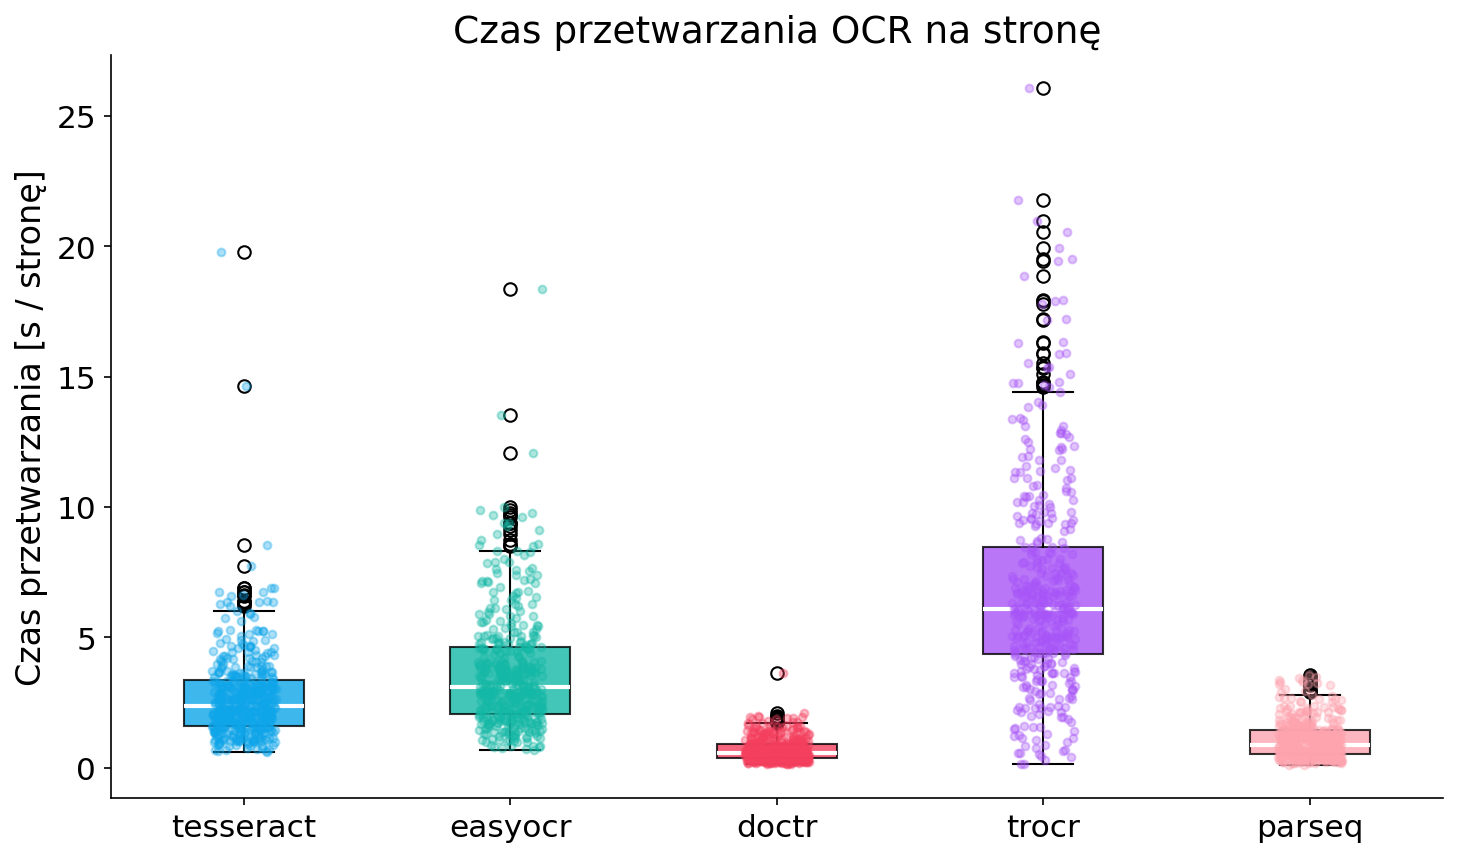

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    data_by_engine,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
    widths=0.45,
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

rng = np.random.default_rng(42)
for i, (data, color) in enumerate(zip(data_by_engine, colors), start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(data))
    ax.scatter(i + jitter, data, alpha=0.35, s=14, color=color, zorder=3)

ax.set_xticks(range(1, len(engines_ordered) + 1))
ax.set_xticklabels(engines_ordered)
ax.set_ylabel("Czas przetwarzania [s / stronę]")
ax.set_title("Czas przetwarzania OCR na stronę")
fig.tight_layout()
fig.savefig(CHART_DIR / "01_time_distribution.png", dpi=300)
plt.show()

In [11]:
spd    = df.groupby("engine")["elapsed_s"].agg(["mean", "median"]).round(3)
tess_t = spd.loc["tesseract", "mean"] if "tesseract" in spd.index else spd["mean"].median()
ENG    = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
          if e in spd.index]

rows = []
for e in sorted(ENG, key=lambda x: spd.loc[x, "mean"]):
    r = tess_t / spd.loc[e, "mean"]
    vs = "—" if e == "tesseract" else (f"{r:.1f}× szybszy" if r > 1 else f"{r:.2f}× (wolniejszy)")
    rows.append({"silnik": e,
                 "średni [s]": spd.loc[e, "mean"],
                 "mediana [s]": spd.loc[e, "median"],
                 "vs Tesseract": vs})

display(pd.DataFrame(rows).set_index("silnik"))
    


,średni [s],mediana [s],vs Tesseract
silnik,,,
doctr,0.687,0.573,4.0× szybszy
parseq,1.078,0.869,2.5× szybszy
tesseract,2.731,2.368,—
easyocr,3.633,3.100,0.75× (wolniejszy)
trocr,6.846,6.079,0.40× (wolniejszy)


Pod kątem szybkości przetwarzania ***docTR*** osiąga zdecydowanie najlepszy wynik. Zaraz za nim plasuję się ***PARSeq***. Oba silniki posługują się tym samym detektorem (DBNet), ale używają innych systemów rozpoznawania. W przypadku ***docTR*** jest to sieć konwolucyjno-rekurencyjna z dekoderem CTC (CRNN), która przetwarza cały fragment równolegle co korzystnie wpływa na szybkość. W przypadku ***parseq*** Vision Transformer rozpoznaje znaki względem kontekstu między nimi.<br>
***TrOCR*** działa najwolniej, co jest konsekwencją sekwencyjnego dekodera, w przypadku zastosowania którego czas pracy rośnie proporcjonalnie do liczby tokenów na stronie.

## Średni czas przetwarzania według typu dokumentu

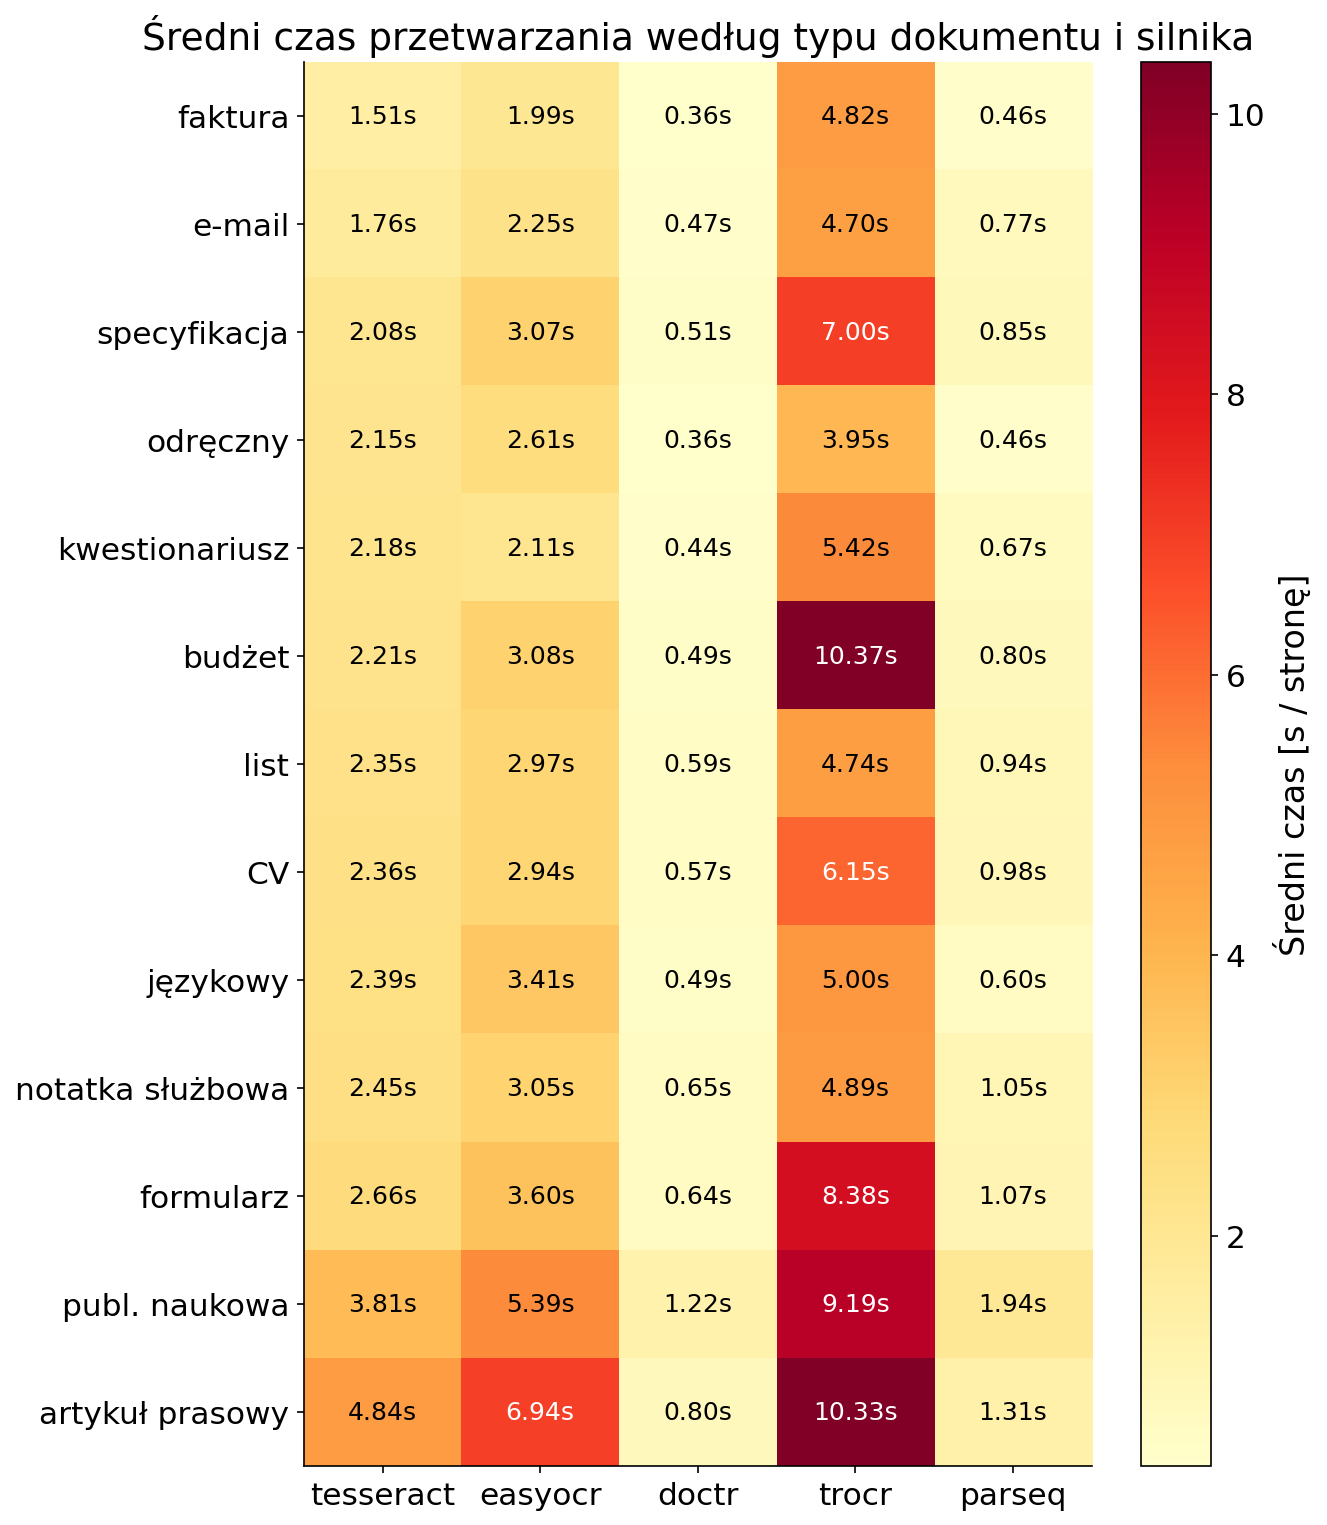

In [12]:
scatter_df = (
    df.groupby(["doc_type_pl", "engine"])
    .agg(mean_time=("elapsed_s", "mean"), mean_words=("word_count", "mean"))
    .reset_index()
)

engines_heat = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"] if e in scatter_df["engine"].unique()]
pivot = (
    scatter_df
    .pivot(index="doc_type_pl", columns="engine", values="mean_time")
    [engines_heat]
    .sort_values(by=engines_heat[0])
)

fig, ax = plt.subplots(figsize=(9, max(7, len(pivot) * 0.65 + 2)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(engines_heat)))
ax.set_xticklabels(engines_heat)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index)

vmax = pivot.values.max()
for r, doc_type in enumerate(pivot.index):
    for c, engine in enumerate(engines_heat):
        val = pivot.loc[doc_type, engine]
        text_color = "white" if val > 0.55 * vmax else "black"
        ax.text(c, r, f"{val:.2f}s", ha="center", va="center",
                fontsize=12, color=text_color)

plt.colorbar(im, ax=ax, label="Średni czas [s / stronę]")
ax.set_title("Średni czas przetwarzania według typu dokumentu i silnika")
fig.tight_layout()
fig.savefig(CHART_DIR / "05_time_heatmap.png", dpi=300)
plt.show()

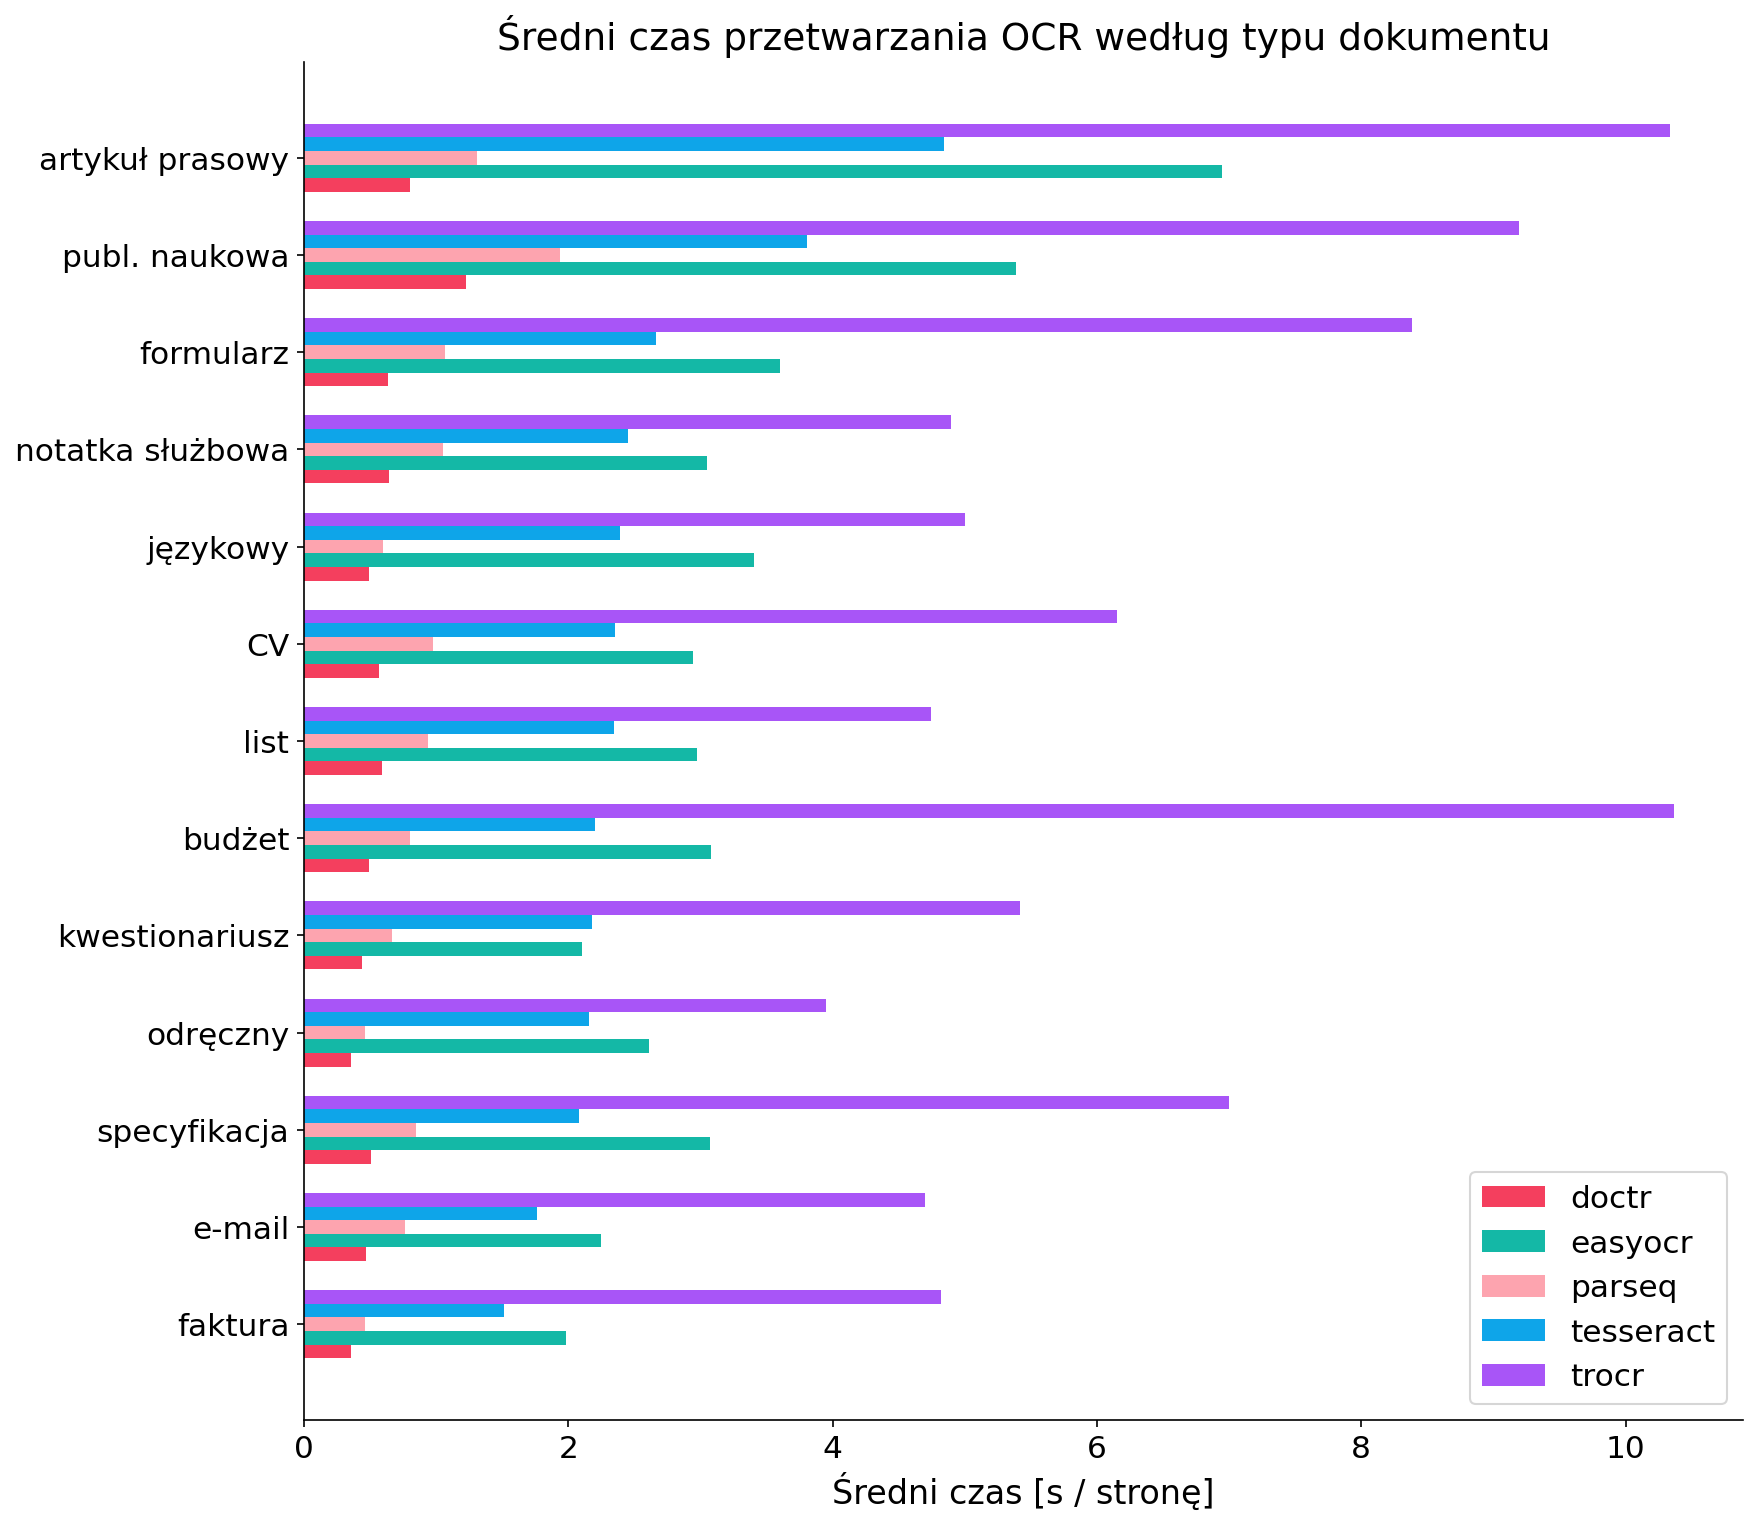

In [13]:
pivot_time = (
    df.groupby(["doc_type_pl", "engine"])["elapsed_s"]
    .mean()
    .unstack("engine")
    .sort_values(by="tesseract", ascending=True)
)

n_engines = len(pivot_time.columns)
width = 0.7 / n_engines

fig, ax = plt.subplots(figsize=(12, max(7, len(pivot_time) * 0.65 + 2)))
x = np.arange(len(pivot_time))

for i, engine in enumerate(pivot_time.columns):
    offset = (i - n_engines / 2 + 0.5) * width
    ax.barh(x + offset, pivot_time[engine], height=width,
            label=engine, color=PALETTE.get(engine, "grey"))

ax.set_yticks(x)
ax.set_yticklabels(pivot_time.index)
ax.set_xlabel("Średni czas [s / stronę]")
ax.set_title("Średni czas przetwarzania OCR według typu dokumentu")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "02_time_by_type.png", dpi=300)
plt.show()

In [14]:
pt = (df.groupby(["doc_type_pl", "engine"])["elapsed_s"]
        .mean()
        .unstack("engine")
        [[e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
          if e in df["engine"].unique()]]
        .round(3)
        .sort_values(by="tesseract", ascending=False))

display(pt)

engine,tesseract,easyocr,doctr,trocr,parseq
doc_type_pl,,,,,
artykuł prasowy,4.842,6.944,0.801,10.333,1.308
publ. naukowa,3.810,5.391,1.225,9.190,1.937
formularz,2.661,3.600,0.637,8.383,1.067
notatka służbowa,2.453,3.053,0.648,4.893,1.052
językowy,2.389,3.409,0.490,5.002,0.599
CV,2.356,2.942,0.570,6.149,0.979
list,2.347,2.972,0.589,4.742,0.936
budżet,2.206,3.080,0.490,10.369,0.805
kwestionariusz,2.177,2.106,0.438,5.420,0.668


***DocTR*** utrzymuję pierwsze miejsce w przypadku wszystkich 13 kategorii dokumentów, a ***PARSeq*** również konsekwentnie zajmuje drugie miejsce.<br>

Czas przetwarzania rośnie proporcjonalnie do gęstości tekstu.<br>
Wszystkie silniki najwolniej przetwarzają publikacje naukowe i artykuły prasowe, a faktury i wiadomości mailowe najszybsze. Efekt jest szczególnie widoczny w przypadku ***TrOCR*** - dla artykułów prasowych osiąga ponad 10 sekund na strone, czyli trzynastokrotnie więcej niż ***docTR***, ponieważ każde słowo to dodatkowy token do zakodowania.

## Rozkład wskaźnika pewności (confidence)

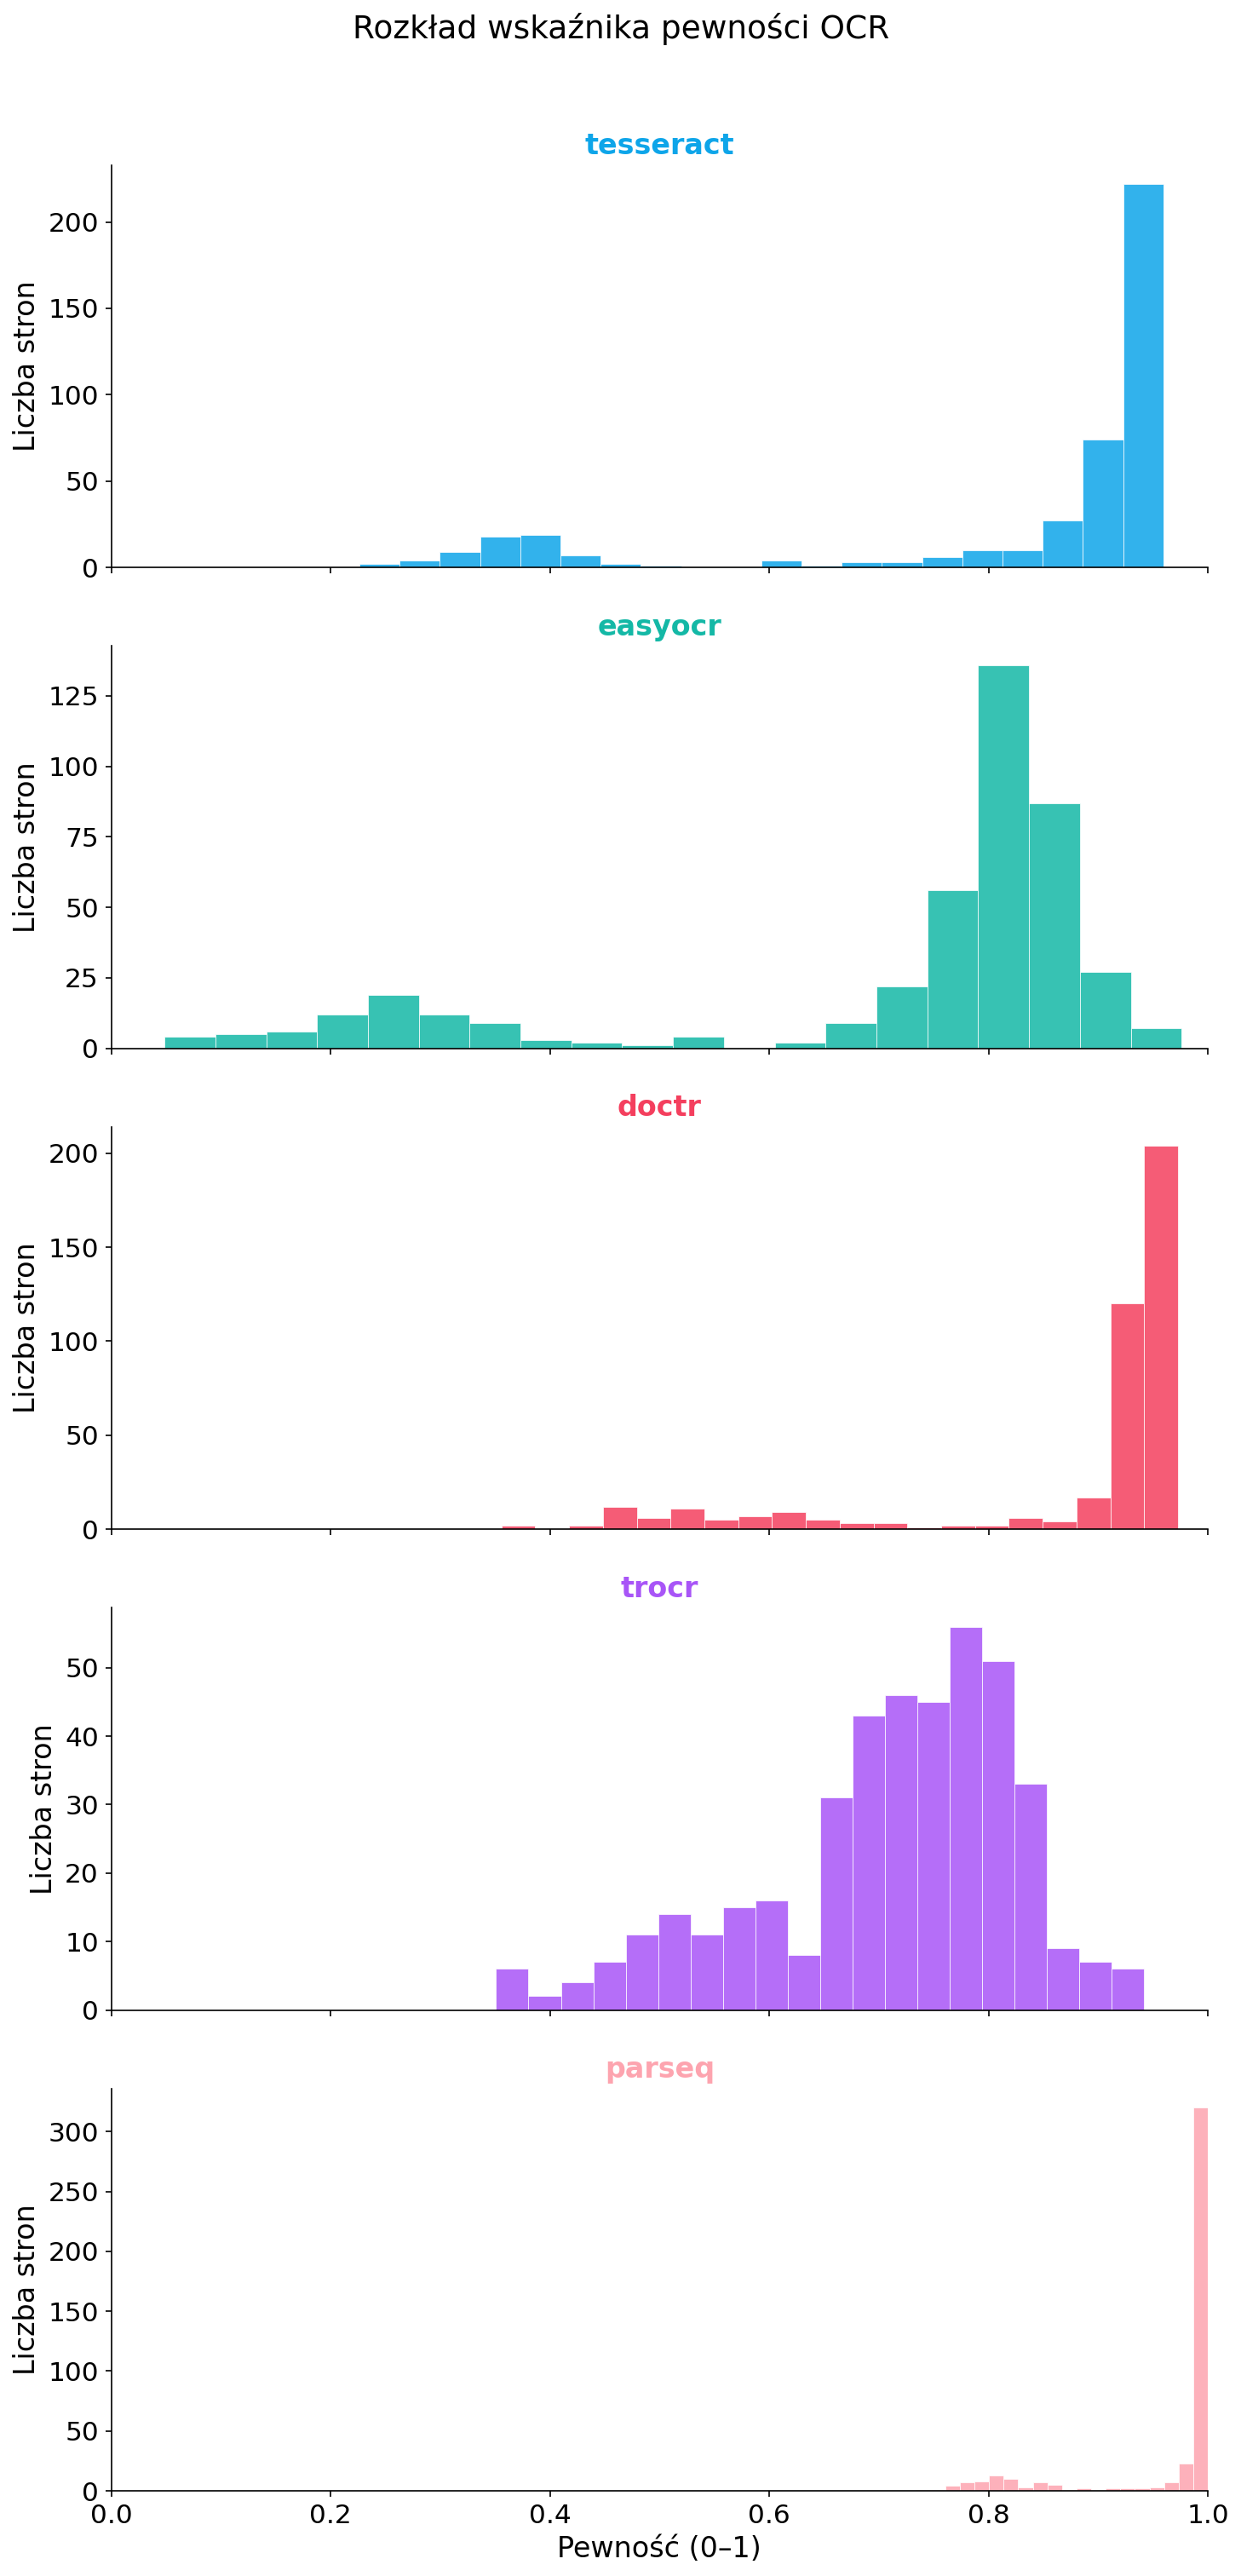

In [15]:
conf_df = df[df["confidence"] >= 0]
engines_with_conf = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"] if e in conf_df["engine"].unique()]
n = len(engines_with_conf)

fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, engine in zip(axes, engines_with_conf):
    data = conf_df[conf_df["engine"] == engine]["confidence"]
    color = PALETTE.get(engine, "grey")
    ax.hist(data, bins=20, color=color, alpha=0.85,
            edgecolor="white", linewidth=0.4)
    ax.set_title(engine, fontsize=16, fontweight="bold", color=color)
    ax.set_ylabel("Liczba stron")
    ax.set_xlim(0, 1)

axes[-1].set_xlabel("Pewność (0–1)")
fig.suptitle("Rozkład wskaźnika pewności OCR", fontsize=18, y=1.01)
fig.tight_layout()
fig.savefig(CHART_DIR / "03_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
cdf = df[df["confidence"] >= 0]
ENG = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
       if e in cdf["engine"].unique()]

rows = []
for e in ENG:
    s = cdf[cdf["engine"] == e]["confidence"]
    rows.append({
        "silnik":      e,
        "średnia":     round(s.mean(), 3),
        "mediana":     round(s.median(), 3),
        "p10":         round(s.quantile(0.1), 3),
        "p25":         round(s.quantile(0.25), 3),
        "p75":         round(s.quantile(0.75), 3),
        "p90":         round(s.quantile(0.9), 3),
        "stron ≥ 0.8": f"{(s >= 0.8).mean() * 100:.1f}%",
    })

display(pd.DataFrame(rows).set_index("silnik").sort_values("średnia", ascending=False))

,średnia,mediana,p10,p25,p75,p90,stron ≥ 0.8
silnik,,,,,,,
parseq,0.968,0.997,0.826,0.988,1.000,1.000,95.2%
doctr,0.878,0.941,0.582,0.914,0.953,0.962,83.8%
tesseract,0.832,0.925,0.383,0.866,0.945,0.954,79.6%
easyocr,0.719,0.810,0.270,0.737,0.844,0.879,55.6%
trocr,0.709,0.733,0.523,0.658,0.794,0.829,23.0%


***PARSeq*** wyróżnia się jako wyraźny lider z medianą pewności 0,997 i z 95,2% stron powyżej progu 0,8.<br>
Wynika to z faktu, że jest trenowany na wszystkich permutacjach kolejności tokenów jednocześnie, co skutkuje bardzo dużą pewnością swoich decyzji.<br><BR>
Bardzo niska pewność ***TorOCR*** jest tylko pozorna. To arfefakt metodologiczny wynikający z tego, że model raportuje jedynie maksymalne prawdopodobieństwo tokenu z dekodera seq2seq, czego nie można porównać z pewnością na poziomie słowa w przypadku pozostałych modeli.

## CER według typu dokumentu (strony z warstwą tekstową)

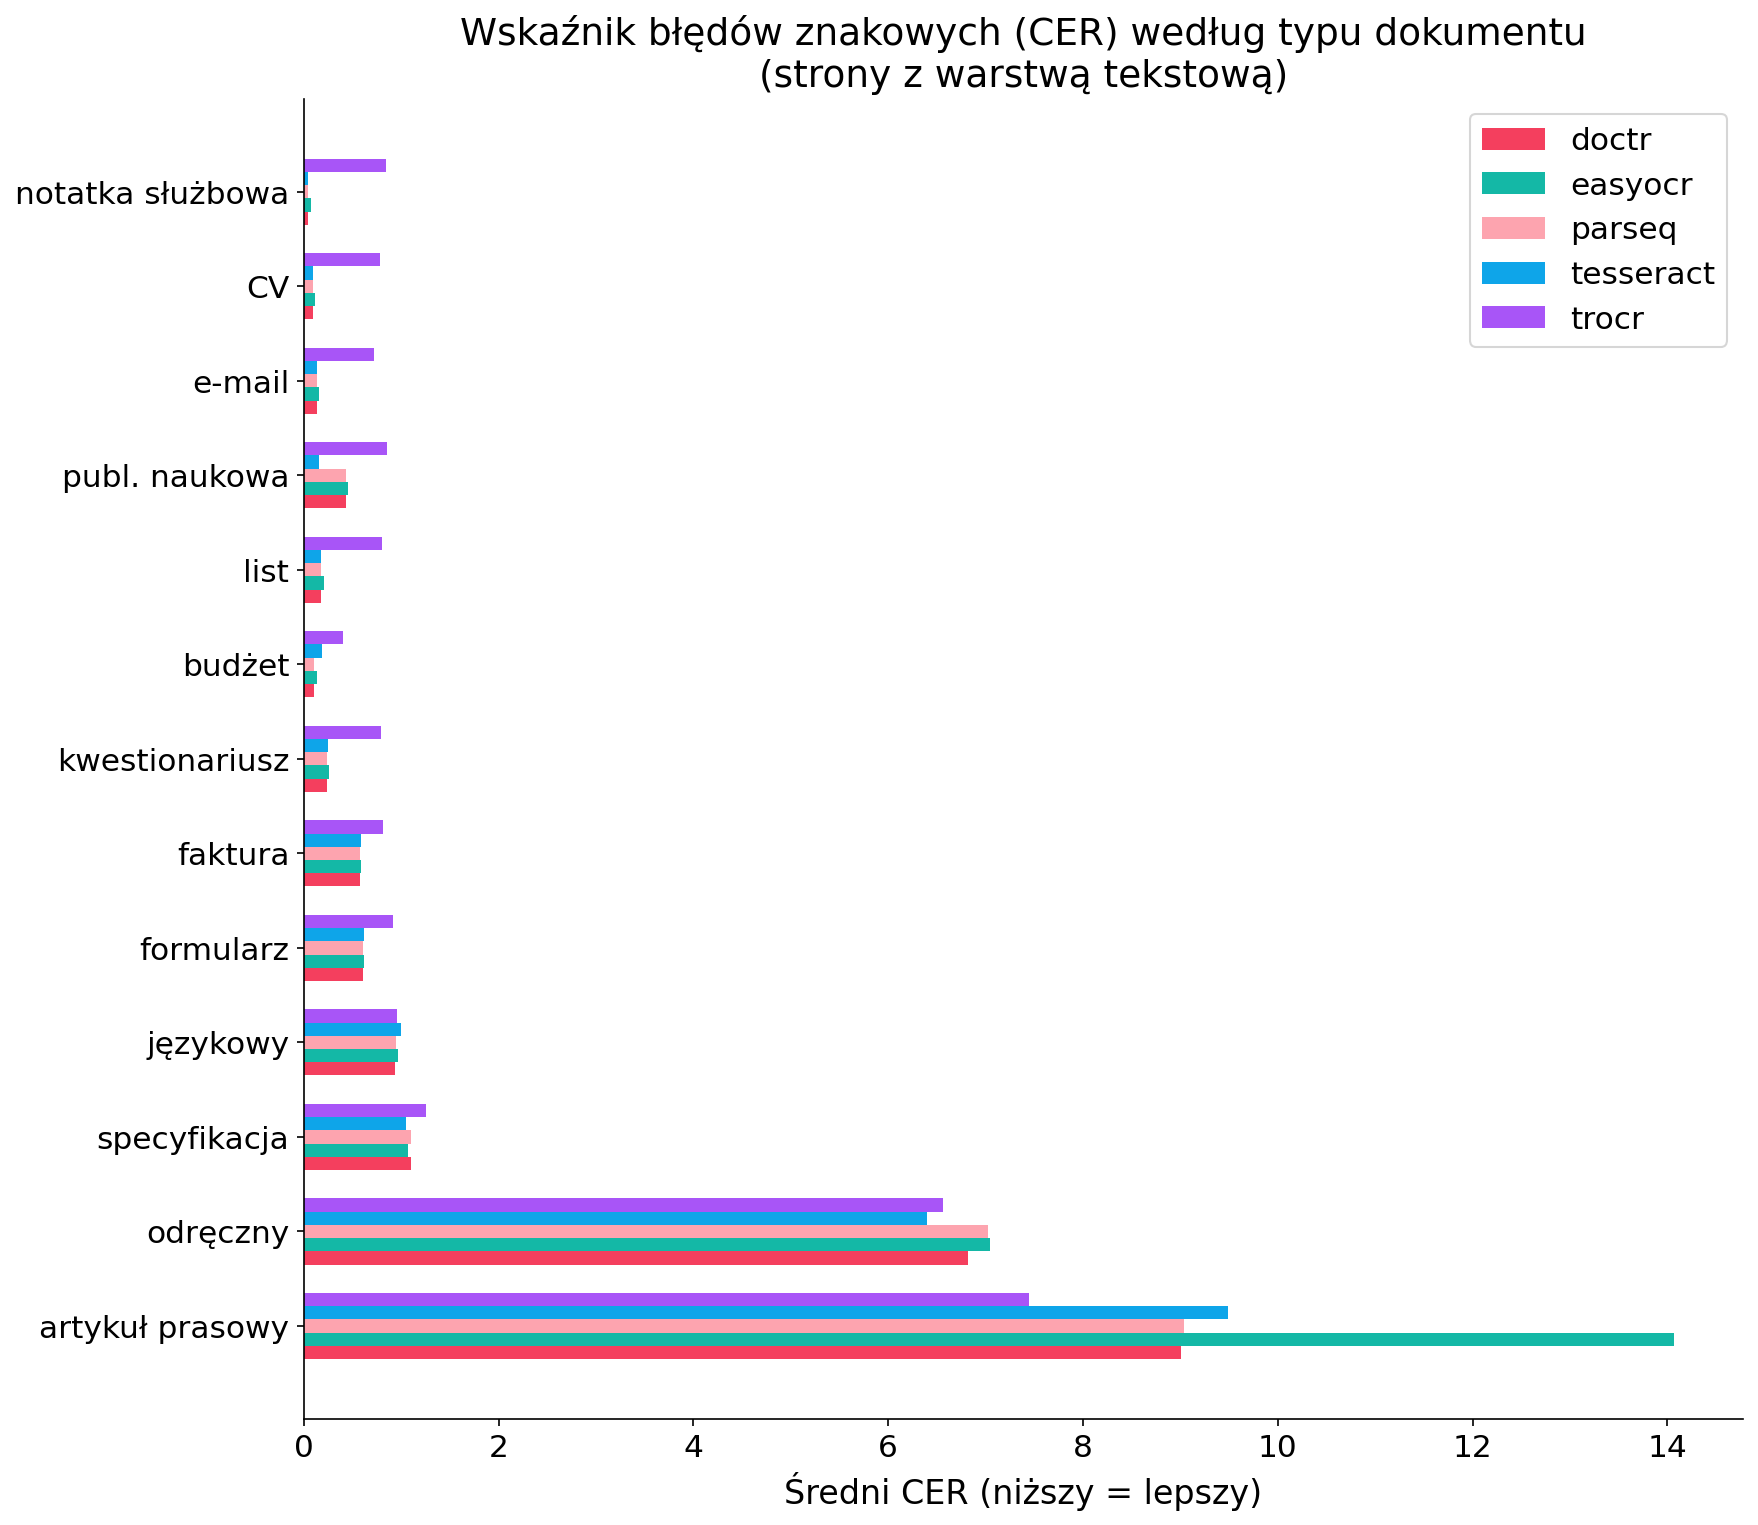

In [17]:
cer_df = df[(df["has_embedded_text"]) & (df["cer"] >= 0)]

if cer_df.empty:
    print("Brak stron z warstwą tekstową — wykres CER pominięty.")
else:
    first_engine = cer_df["engine"].iloc[0]
    pivot_cer = (
        cer_df.groupby(["doc_type_pl", "engine"])["cer"]
        .mean()
        .unstack("engine")
        .sort_values(by=first_engine, ascending=False)
    )

    n_engines = len(pivot_cer.columns)
    width = 0.7 / n_engines

    fig, ax = plt.subplots(figsize=(12, max(7, len(pivot_cer) * 0.65 + 2)))
    x = np.arange(len(pivot_cer))

    for i, engine in enumerate(pivot_cer.columns):
        offset = (i - n_engines / 2 + 0.5) * width
        ax.barh(x + offset, pivot_cer[engine], height=width,
                label=engine, color=PALETTE.get(engine, "grey"))

    ax.set_yticks(x)
    ax.set_yticklabels(pivot_cer.index)
    ax.set_xlabel("Średni CER (niższy = lepszy)")
    ax.set_title("Wskaźnik błędów znakowych (CER) według typu dokumentu\n(strony z warstwą tekstową)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(CHART_DIR / "04_cer_by_type.png", dpi=300)
    plt.show()

In [18]:
ok  = df[df["has_embedded_text"] & (df["cer"] >= 0)]
ENG = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
       if e in ok["engine"].unique()]

rows = []
for e in ENG:
    s = ok[ok["engine"] == e]["cer"]
    rows.append({
        "silnik":   e,
        "średnia":  round(s.mean(), 3),
        "mediana":  round(s.median(), 3),
        "p10":      round(s.quantile(0.1), 3),
        "p25":      round(s.quantile(0.25), 3),
        "p75":      round(s.quantile(0.75), 3),
        "p90":      round(s.quantile(0.9), 3),
    })

display(pd.DataFrame(rows).set_index("silnik").sort_values("mediana"))

,średnia,mediana,p10,p25,p75,p90
silnik,,,,,,
tesseract,0.871,0.127,0.023,0.047,0.660,0.872
doctr,0.956,0.257,0.023,0.050,0.759,0.946
parseq,0.969,0.258,0.023,0.050,0.762,0.954
easyocr,1.125,0.308,0.047,0.076,0.771,0.890
trocr,1.310,0.851,0.695,0.783,0.884,0.982


In [19]:
pc = (ok.groupby(["doc_type_pl", "engine"])["cer"]
        .mean()
        .unstack("engine")
        [[e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
          if e in ok["engine"].unique()]]
        .round(3)
        .sort_values(by="tesseract", ascending=False))

display(pc)

engine,tesseract,easyocr,doctr,trocr,parseq
doc_type_pl,,,,,
artykuł prasowy,9.486,14.072,9.009,7.446,9.034
odręczny,6.395,7.043,6.822,6.560,7.021
specyfikacja,1.051,1.072,1.096,1.250,1.103
językowy,1.002,0.971,0.931,0.961,0.946
formularz,0.621,0.615,0.602,0.913,0.603
faktura,0.587,0.586,0.574,0.814,0.574
kwestionariusz,0.251,0.258,0.235,0.796,0.235
budżet,0.185,0.131,0.105,0.404,0.105
list,0.174,0.210,0.178,0.803,0.178


Zgodnie z przewidywaniami wynikającymi z architektury różnica między ***docTR*** a ***PARSeq*** jest minimalna dla większości kategorii. Dla dziewięciu z nich odchylenie CER wynosi poniżej 0,001.
Przy tym samym detektorze (DBNet) zmiana systemu rozpoznawania nie przynosi istotnej zmiany w dokładności transkrypcji.<br><br>

***Tesseract*** charakteryzuje się klasyczną budową opartą na LSTM i trenowaniem na rozpoznawaniu znaków. Jest pozbawiony modułu językowego który rozumie co czyta. To pozorne ograniczenie okazuje się zaletą w przypadku kategorii bogatych w inne wzorce niż naturalny tekst przyminający naturalny język ciągły. Specyfikacje, CV, e-maile, listy i publikacje naukowe zawierają dużo takich treści: numery katalogowe, daty, kody produktów, nagłowki sekcji. Silniki neuronowe wyposażone w mechanizm attention uczą się statystycznych wzorców języka i czasami poprawiają tego typu treści zgodnie z tym co jest najbardziej prawdopodobnego jeżykowo, podczas gdy ***Tesseract*** jest pozbawiony tego problemu.



## Wnioski ogólne

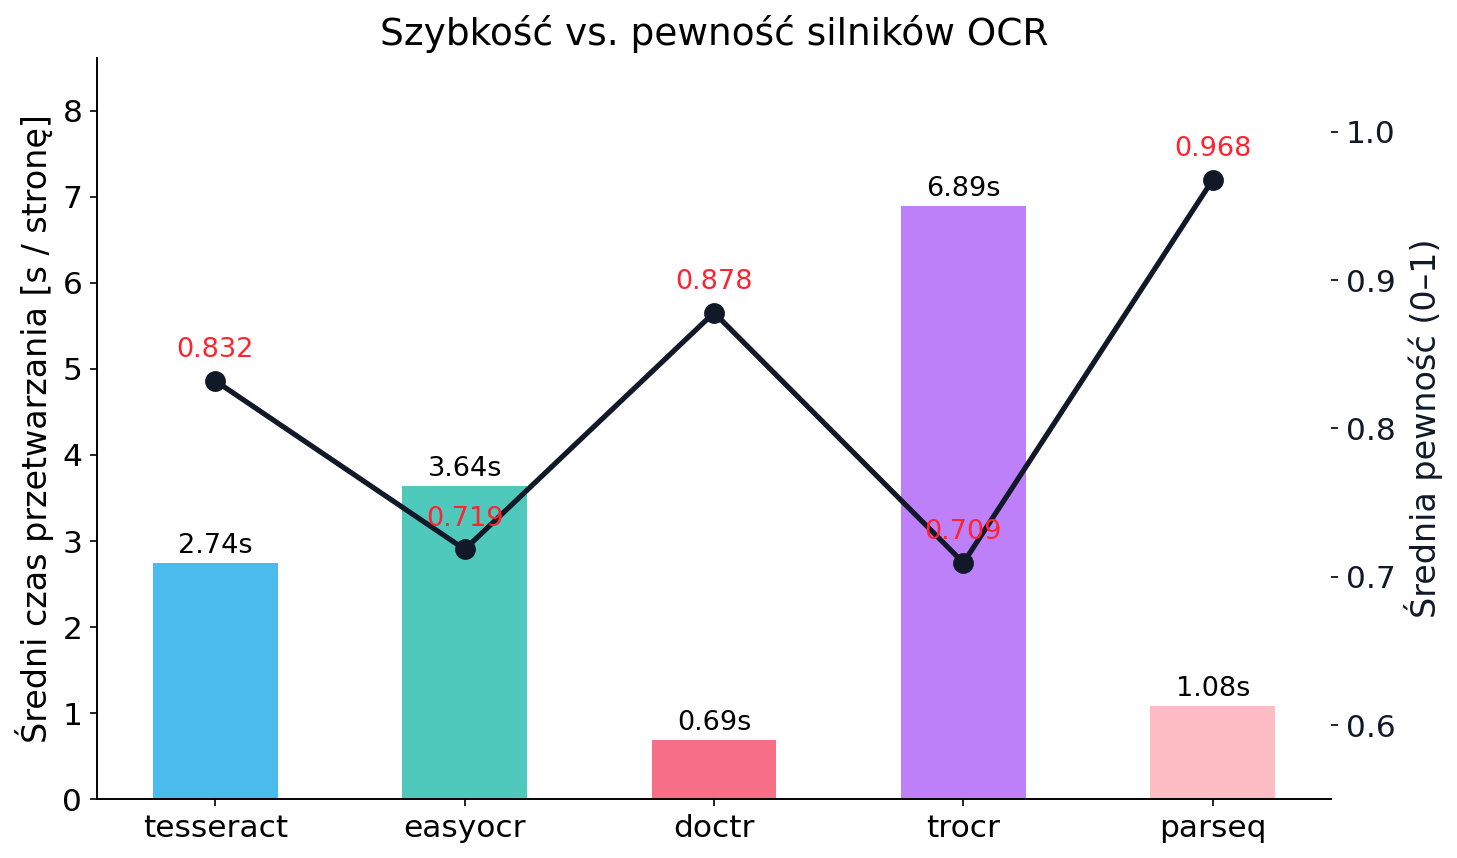

In [29]:
## Wykres 6 — Szybkość i pewność łącznie (słupki + krzywa)

eng_order = [e for e in ["tesseract", "easyocr", "doctr", "trocr", "parseq"]
             if e in df["engine"].unique()]

agg = (
    df[df["confidence"] >= 0]
    .groupby("engine")[["elapsed_s", "confidence"]]
    .mean()
    .loc[eng_order]
)

x      = np.arange(len(eng_order))
colors = [PALETTE[e] for e in eng_order]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# --- słupki: czas przetwarzania (oś lewa) ---
bars = ax1.bar(x, agg["elapsed_s"], color=colors, alpha=0.75, width=0.5, zorder=2)
ax1.set_ylabel("Średni czas przetwarzania [s / stronę]", color="black")
ax1.set_ylim(0, agg["elapsed_s"].max() * 1.25)
ax1.set_xticks(x)
ax1.set_xticklabels(eng_order)
ax1.tick_params(axis="y", labelcolor="black")

# wartości nad słupkami
for bar, val in zip(bars, agg["elapsed_s"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.2f}s", ha="center", va="bottom", fontsize=13, color="black")

# --- krzywa: pewność (oś prawa) ---
ax2.plot(x, agg["confidence"], color="#111827", linewidth=2.5,
         marker="o", markersize=9, zorder=3, label="pewność (mean)")
ax2.set_ylabel("Średnia pewność (0–1)", color="#111827")
ax2.set_ylim(0.55, 1.05)
ax2.tick_params(axis="y", labelcolor="#111827")

# etykiety wartości przy punktach
for xi, val in zip(x, agg["confidence"]):
    ax2.text(xi, val + 0.012, f"{val:.3f}", ha="center", va="bottom",
             fontsize=13, color="#FD242F")

# --- usuwamy górną i prawą ramkę tylko dla ax1 (ax2 rządzi prawą osią) ---
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax1.set_title("Szybkość vs. pewność silników OCR")
fig.tight_layout()
fig.savefig(CHART_DIR / "06_speed_vs_confidence.png", dpi=300)
plt.show()

Spośród analizowanych silników ***docTR*** oferuje najlepszy kompromis pomiędzy szybkością przetwarzania, a jakością wyjściowych plików i to on zostanie wykorzystany w dalszej części pracy.<br><br>

***Tesseract*** osiągnał niższy CER w sześciu kategoriach, ale tylko dla dwóch z nich różnica CER wzgledem ***docTR*** przekracza 0,05. Jednocześnie ***docTR*** osiąga przewagę w pewności i jest aż czeterokrotnie szybszy.

***EasyOCR*** jest najwolniejszy spośród silników klasycznych i nie wygrywa w żadnej kategorii CER. ***TrOCR***, choć osiąga najniższy CER na artykułach prasowych, jest 10× wolniejszy od docTR i jednocześnie najgorszy pod względem CER na 11 z 13 typów dokumentów — co czyni go nieprzydatnym jako silnik ogólnego zastosowania w kontekście zbadanego zbioru danych.
